The objective of Phase 1 is to analyze the historical behavior of stock prices, understand volatility, and examine the relationship between trading volume and price movement using statistical techniques.


In [146]:
import pandas as pd

df = pd.read_csv("data/stocks/TSLA.csv")  # use any one stock
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [147]:
# Daily Return
df['Daily_Return'] = df['Adj Close'].pct_change()

# Target for future prediction
df['Target_Next_Day_Close'] = df['Adj Close'].shift(-1)

# Drop NaN values
df = df.dropna()

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,-0.002511,21.959999
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,-0.078473,19.200001
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,-0.125683,16.110001
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,-0.160938,15.800000
5,2010-07-07,16.400000,16.629999,14.980000,15.800000,15.800000,6921700,-0.019243,17.459999


In [148]:
print("Descriptive Statistics:\n")
print(df[['Volume', 'Daily_Return']].describe())

print("\nVariance:\n")
print(df[['Volume', 'Daily_Return']].var())

Descriptive Statistics:

             Volume  Daily_Return
count  2.455000e+03   2455.000000
mean   5.821561e+06      0.001837
std    5.466792e+06      0.034143
min    1.185000e+05     -0.193274
25%    1.960350e+06     -0.014632
50%    4.668100e+06      0.000845
75%    7.522100e+06      0.018152
max    6.093880e+07      0.243951

Variance:

Volume          2.988582e+13
Daily_Return    1.165776e-03
dtype: float64


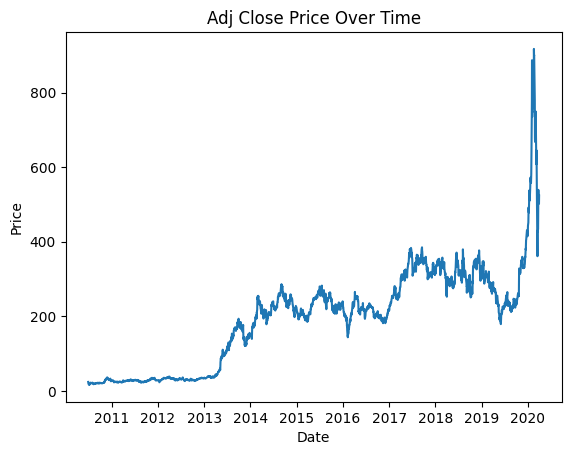

In [149]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['Adj Close'])
plt.title("Adj Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [150]:
df['Volatility'] = df['Daily_Return'].rolling(7).std()

In [151]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    up_days['Volume'],
    down_days['Volume'],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.9733350066613669
P-value: 0.04848648579263966


Null Hypothesis (H0): The mean trading volume on up days is equal to that on down days.

Alternative Hypothesis (H1): The mean trading volume on up days is different from that on down days.

Decision Rule:
If p-value < 0.05, reject H0; otherwise, fail to reject H0.

Conclusion:
Based on the computed p-value, we determine whether trading volume differs significantly between up and down days.

The objective of Phase 2 is to reduce redundancy among highly correlated features (Open, High, Low, Volume) using linear algebra concepts such as covariance, eigenvalues, and eigenvectors. This helps identify the most important underlying factors affecting stock price movement.


In [152]:
from sklearn.model_selection import train_test_split

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target_Next_Day_Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [153]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [154]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
explained_variance = eigenvalues / np.sum(eigenvalues)
print("Explained Variance:\n", explained_variance)

Explained Variance:
 [8.50473448e-01 1.49169673e-01 1.50985341e-04 2.05893974e-04]


In [155]:
import numpy as np

cov_matrix = np.cov(scaled_features, rowvar=False)
print(cov_matrix)

[[1.0004075  0.99964128 0.99962884 0.56798124]
 [0.99964128 1.0004075  0.99915157 0.58134479]
 [0.99962884 0.99915157 1.0004075  0.55702495]
 [0.56798124 0.58134479 0.55702495 1.0004075 ]]


In [156]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [3.40328006e+00 5.96921837e-01 6.04187468e-04 8.23911503e-04]

Eigenvectors:
 [[ 0.53415302 -0.22033527 -0.80527196 -0.13292848]
 [ 0.53556823 -0.19941267  0.51524572 -0.63868857]
 [ 0.53285438 -0.23716982  0.29330575  0.75748823]
 [ 0.37935923  0.92489861 -0.00553576  0.02486967]]


In [157]:
# Index of largest eigenvalue
max_index = np.argmax(eigenvalues)

principal_component = eigenvectors[:, max_index]

print("Principal Component:\n", principal_component)

Principal Component:
 [0.53415302 0.53556823 0.53285438 0.37935923]


The eigenvector corresponding to the largest eigenvalue represents the direction of maximum variance in the data and is known as the principal component.

Since Open, High, and Low are highly correlated, they do not provide independent information. By transforming the data using eigenvectors, we obtain a new set of orthogonal (independent) basis vectors.

This allows us to:
1. Reduce dimensionality by selecting only the top principal components
2. Remove redundancy in features
3. Improve efficiency and performance of regression models

Thus, instead of using all original features, we can project the data onto fewer principal components while retaining most of the variance.

The objective of Phase 3 is to build predictive models using statistical techniques. Multiple Linear Regression is used to predict future prices, while Logistic Regression is used to classify price direction. Model diagnostics are performed to evaluate reliability and detect influential observations.

In [158]:
from sklearn.model_selection import train_test_split

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target_Next_Day_Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [159]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-6.59155427e-01  7.51721916e-01  9.07413805e-01  1.14742807e-07]
Intercept: 0.16128718179982116


In [160]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))   

R2 Score: 0.9754699714914988


In [161]:
df['Direction'] = (df['Target_Next_Day_Close'] > df['Adj Close']).astype(int)

In [162]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Scale
scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_log_scaled, y_log, test_size=0.2, shuffle=False
)

# Train
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Coefficients:", log_model.coef_)
print("Intercept:", log_model.intercept_)

# Predict
y_pred = log_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Coefficients: [[ 0.5198666  -0.47169556 -0.12311834  0.07911755]]
Intercept: [0.04435873]
Accuracy: 0.5071283095723014


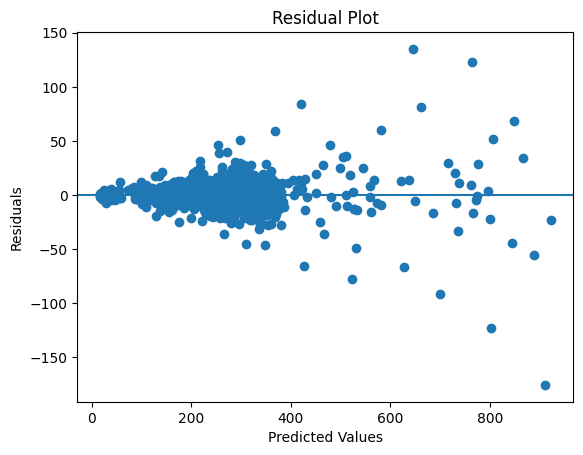

In [168]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)
residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [170]:
import numpy as np

# Simple threshold method
threshold = 2 * np.std(residuals)
outliers = df[np.abs(residuals) > threshold]

print("Outliers:\n", outliers[['Date', 'Adj Close']])

Outliers:
            Date   Adj Close
845  2013-11-05  176.809998
891  2014-01-13  139.339996
919  2014-02-24  217.649994
970  2014-05-07  201.350006
996  2014-06-13  206.419998
...         ...         ...
2448 2020-03-20  427.529999
2449 2020-03-23  434.290009
2450 2020-03-24  505.000000
2454 2020-03-30  502.130005
2455 2020-03-31  524.000000

[79 rows x 2 columns]


Residuals represent the difference between actual and predicted values. A good model should have residuals randomly distributed around zero.

Extreme residual values indicate influential observations, such as market crashes or sudden spikes, which can disproportionately affect model performance.